## LAES optimisation

In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import pandas for data handling
import pandas as pd

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


ModuleNotFoundError: No module named 'CoolProp'

#### Setup tank and cryogen properties

In [39]:
# LNG tank properties
Q_roof = 0              # Roof heat ingress / W
T_air  = 18.08 + 273.15  # Temperature of the environment K

V_tank = 4831 # Tank volume / m^3

a   = 0.5
d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m

# Thickness of the in % of the internal diameter
ST  = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 8.72e-2 # W/m2/K
U_V = 8.72e-2 # W/m2/K

# Set overall bottom heat transfer coefficient respect the r_U
r_U = 0.25
U_b = r_U * U_L # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95

# Wall heat fraction
eta = 0.9

# Specify tank operating pressure
P = 101325*3 # Pa

# # Initialise cryogen
cryogen = Cryogen(name = "nitrogen")
cryogen.set_coolprops(P)

In [40]:
def estimate_transient_period(a, r_U, LF):
    eta_w = 0.9

    d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
    ST  = 1.02
    d_o = d_i * ST # external diameter / m

    # Initialize large-scale tank
    large_tank = Tank(d_i, d_o, V_tank, LF)
    large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = None, Q_roof = 0, eta_w = 0.90)
    large_tank.cryogen = cryogen
    large_tank.U_b = U_L*r_U

    # Minimum number of hours to achieve steady state 
    return large_tank.tau

In [41]:
a  = np.linspace(0.1, 2.5, 500)
a_relation = 1/(a**(1/3))
tau_ru_4_LF95 = estimate_transient_period(a, 4, 0.95)
tau_ru_025_LF95 = estimate_transient_period(a, 0.25, 0.95)

tau_ru_4_LF05 = estimate_transient_period(a, 4, 0.05)
tau_ru_025_LF05 = estimate_transient_period(a, 0.25, 0.05)


In [9]:
pd.DataFrame({
    'a': a,
    'tau_ru_4_LF95': tau_ru_4_LF95,
    'tau_ru_025_LF95': tau_ru_025_LF95,
    'tau_ru_4_LF05': tau_ru_4_LF05,
    'tau_ru_025_LF05': tau_ru_025_LF05
}).to_csv('transient_period_r_U.csv', index=False)

In [42]:
# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = None, Q_roof = 0, eta_w = 0.90)
large_tank.U_b = U_L*r_U

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

The initial evaporation rate of nitrogen is 331.3 kg/h


Calculate initial evaporation rate and transient period

In [43]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of nitrogen is 331.3 kg/h
Transient period = 67353.701 s 
Simulation time: 19 h
BOR = 0.229 %


#### Simulation setup and execution

In [44]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 50 #+ int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 12 hours
evap_time = 3600 * 12

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 1200

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
# large_tank.evaporate(evap_time)

In [45]:
opti = Opti_jax(large_tank)

In [46]:
folder    = "../Results/Data/"
optimos   = pd.read_csv(folder + 'LAES_opti_12h_LFs_ru_025_opts.csv')
optimo_05 = optimos.Optimal_AR[0]
optimo_95 = optimos.Optimal_AR.iloc[-1]
print("Optimal Geometric AR for LF=0.95: ", optimo_95)
print("Optimal Geometric AR for LF=0.05: ", optimo_05)

Optimal Geometric AR for LF=0.95:  0.1259647535423311
Optimal Geometric AR for LF=0.05:  0.1399305712118524


In [30]:
optimo_95

np.float64(0.1259647535423311)

In [49]:
# Exportar perfil de temperatura
opti.time = 3600 * 24 * 30
opti_ar   = optimo_95
sol       = opti.evaporate(opti_ar)

# Convert sol.ys[:,1:] to DataFrame
df_sol = pd.DataFrame(sol.ys[:,1:])
df_sol.insert(0, "Time (s)", sol.ts)

# Export to CSV
folder = "../Results/Data/"
df_sol.to_csv(folder + 'T_V_LF95_30days_ru_05.csv', index=False)

optimal Aspect Ratio: [0.13997725 0.13927655 0.13867595 0.13807535 0.13747475 0.13677405
 0.13617345 0.13557285 0.13497224 0.13437164 0.13387114 0.13327054
 0.13266994 0.13206934 0.13156884 0.13096824 0.13036764 0.12986714
 0.12926654 0.12876604 0.12826554 0.12766494 0.12716444 0.12666394
 0.12596324]
optimal Thermal Aspect Ratio: [0.66975112 0.66955551 0.66951029 0.66945718 0.66939617 0.66916528
 0.66908771 0.6690022  0.66890875 0.66880733 0.66886366 0.66874705
 0.66862244 0.6684898  0.66851785 0.66836993 0.66821395 0.66822087
 0.66804951 0.66804254 0.66802894 0.66783484 0.6678073  0.66777313
 0.6673798 ]
optimal BOR: [0.03376852 0.01935239 0.01358588 0.01048079 0.00854006 0.00721217
 0.0062464  0.00551239 0.00493565 0.00447051 0.00408744 0.00376648
 0.00349364 0.00325886 0.00305469 0.00287551 0.002717   0.00257576
 0.00244913 0.00233493 0.00223143 0.00213718 0.00205098 0.00197182
 0.00189873]


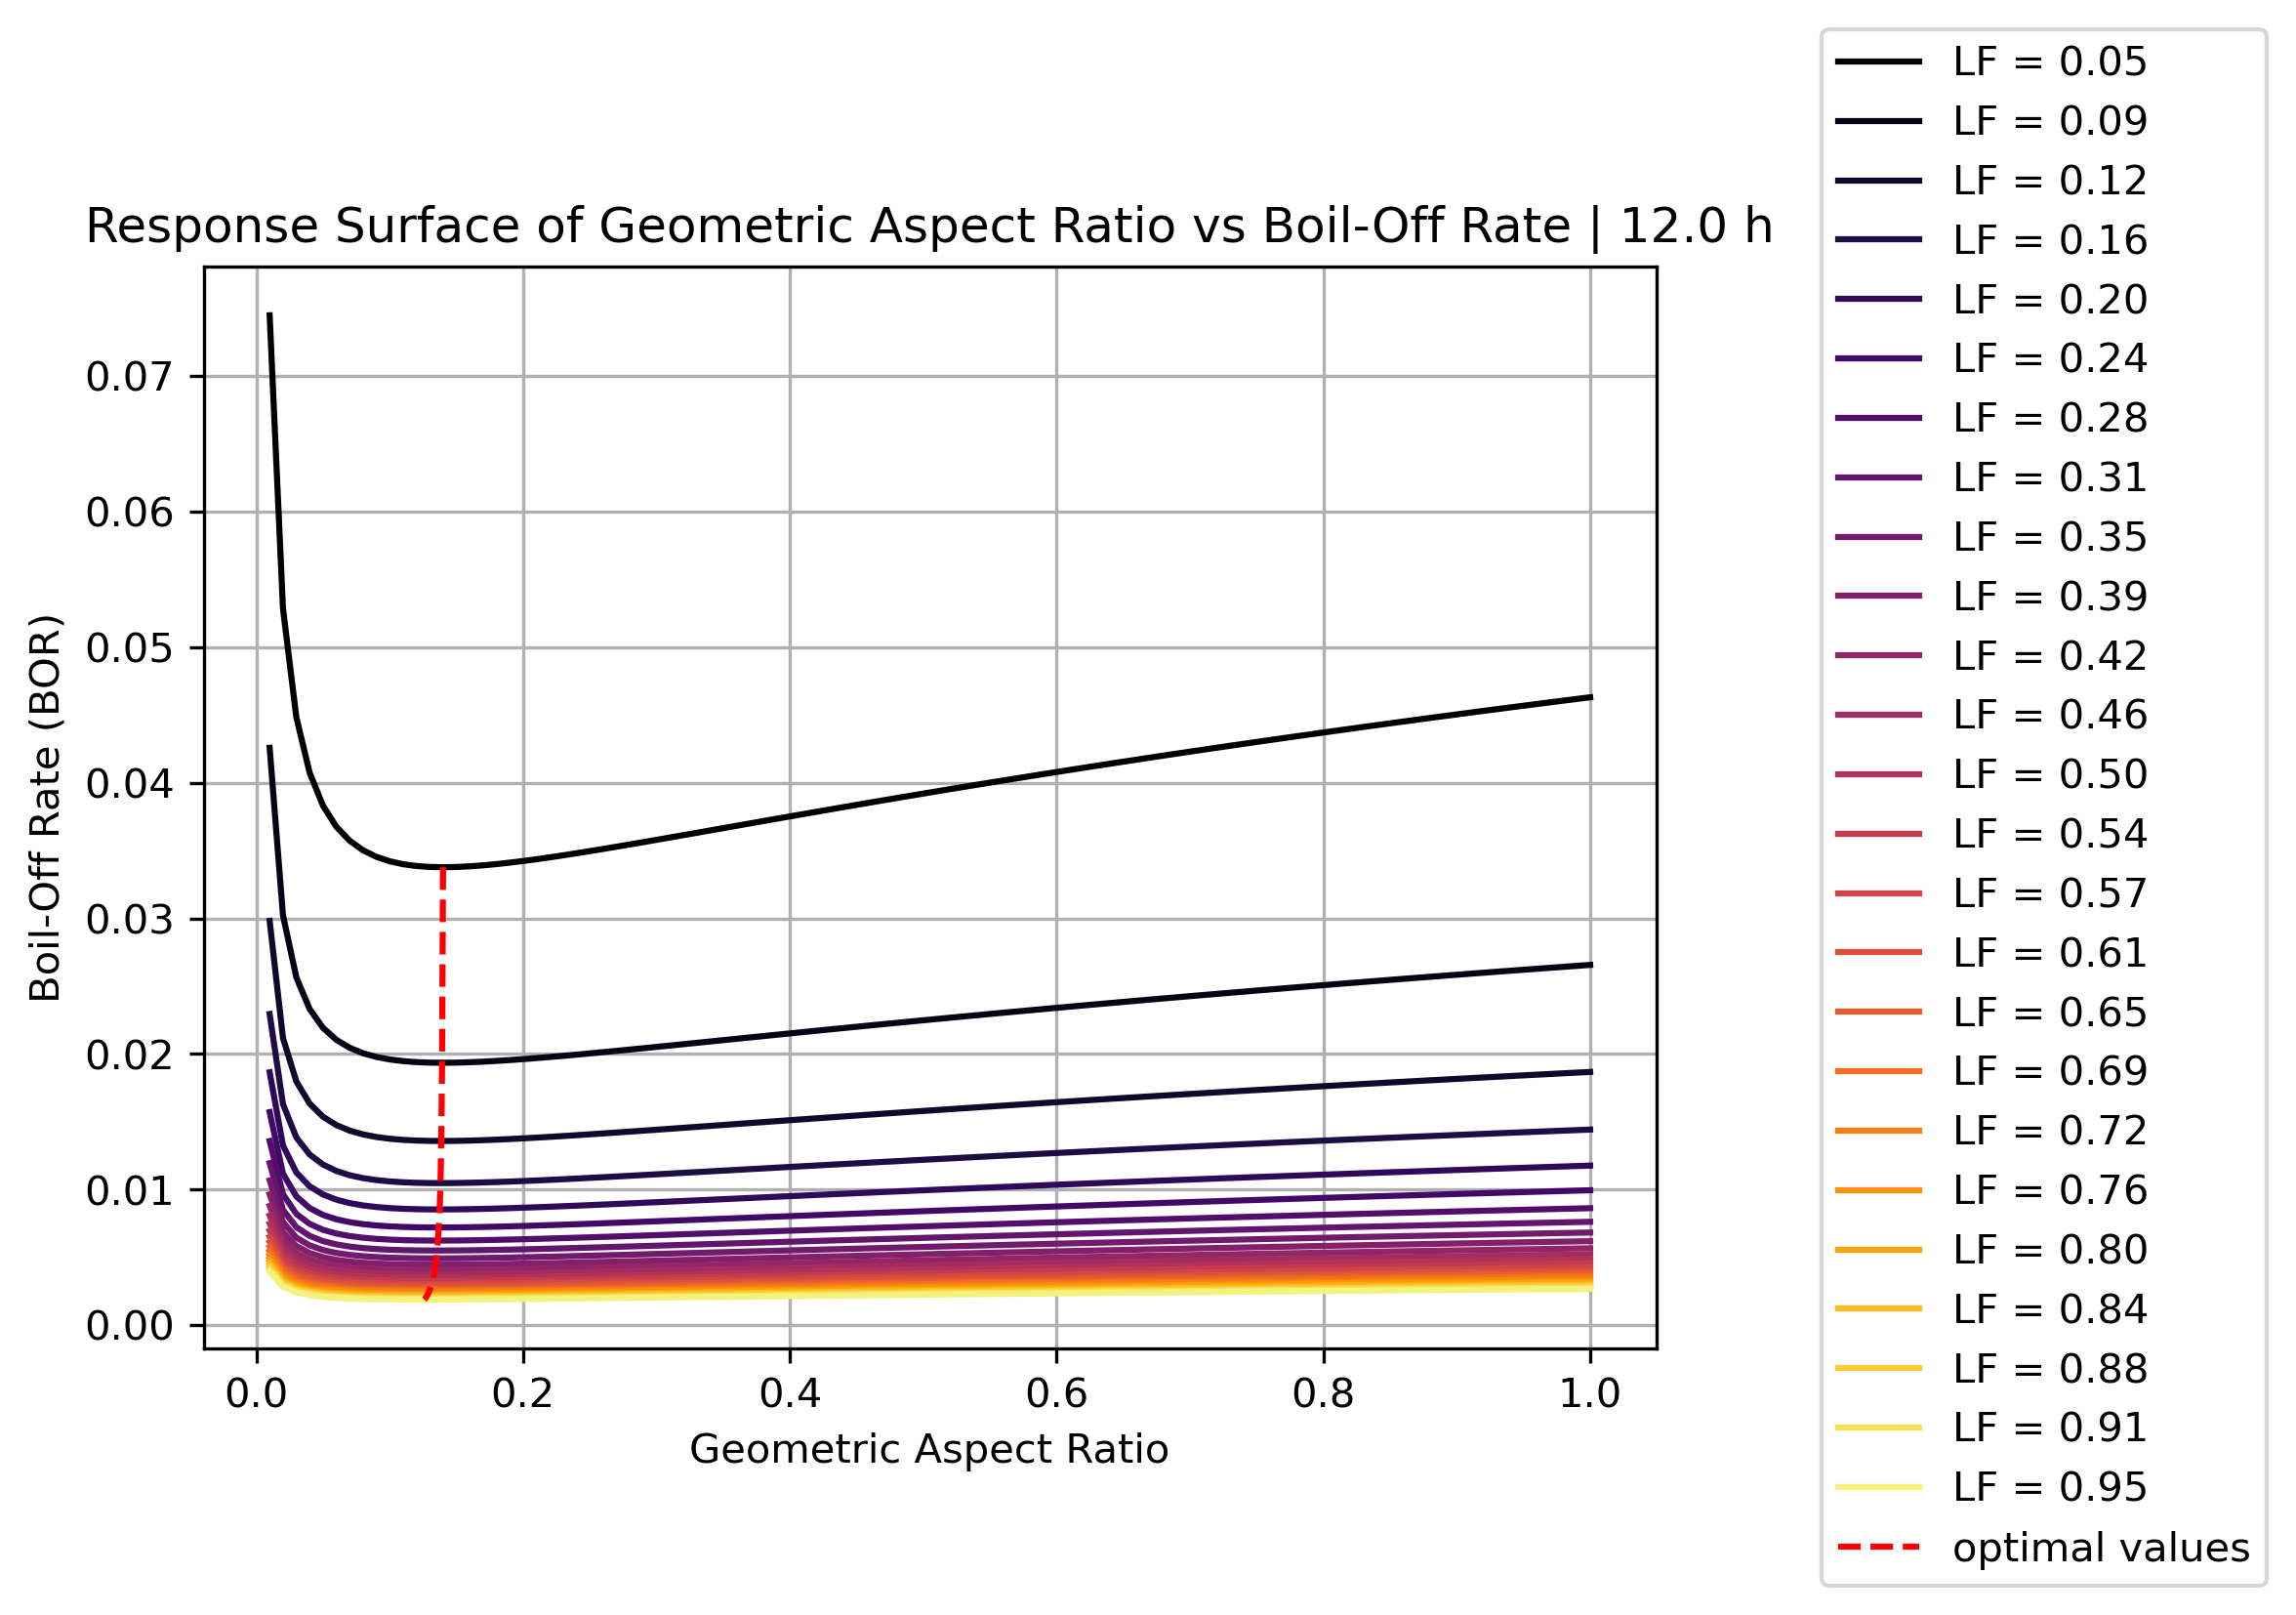

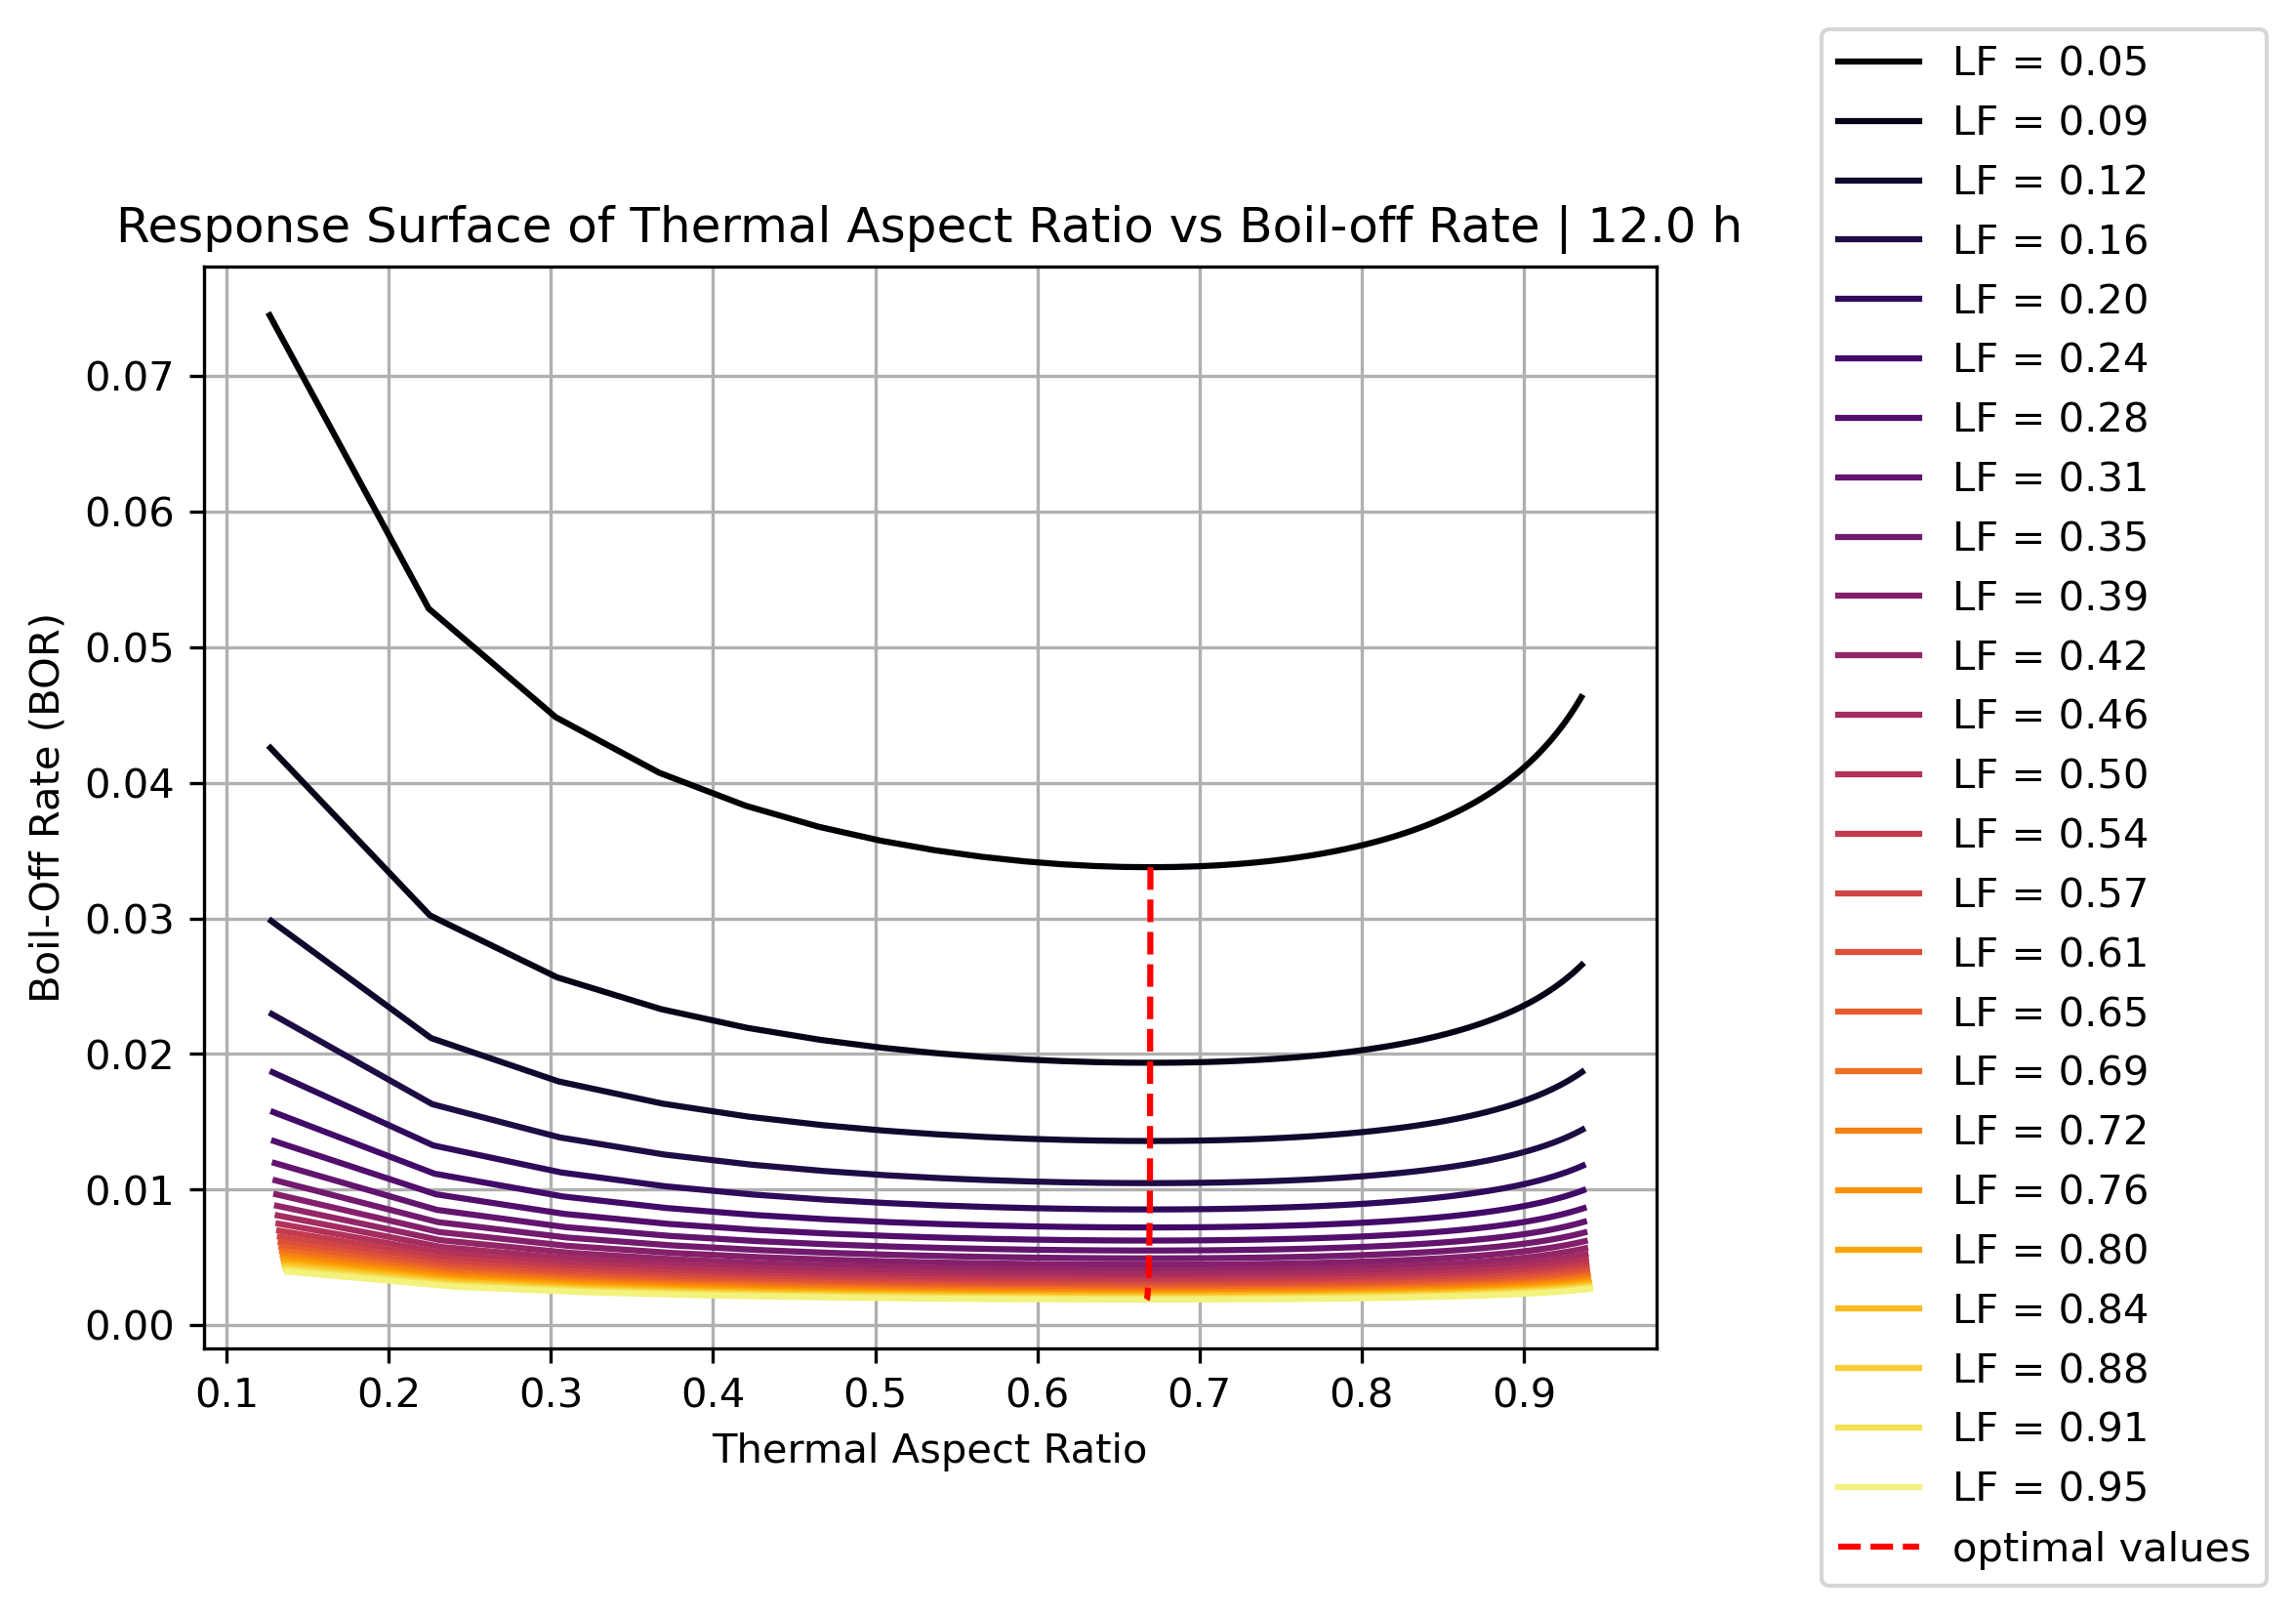

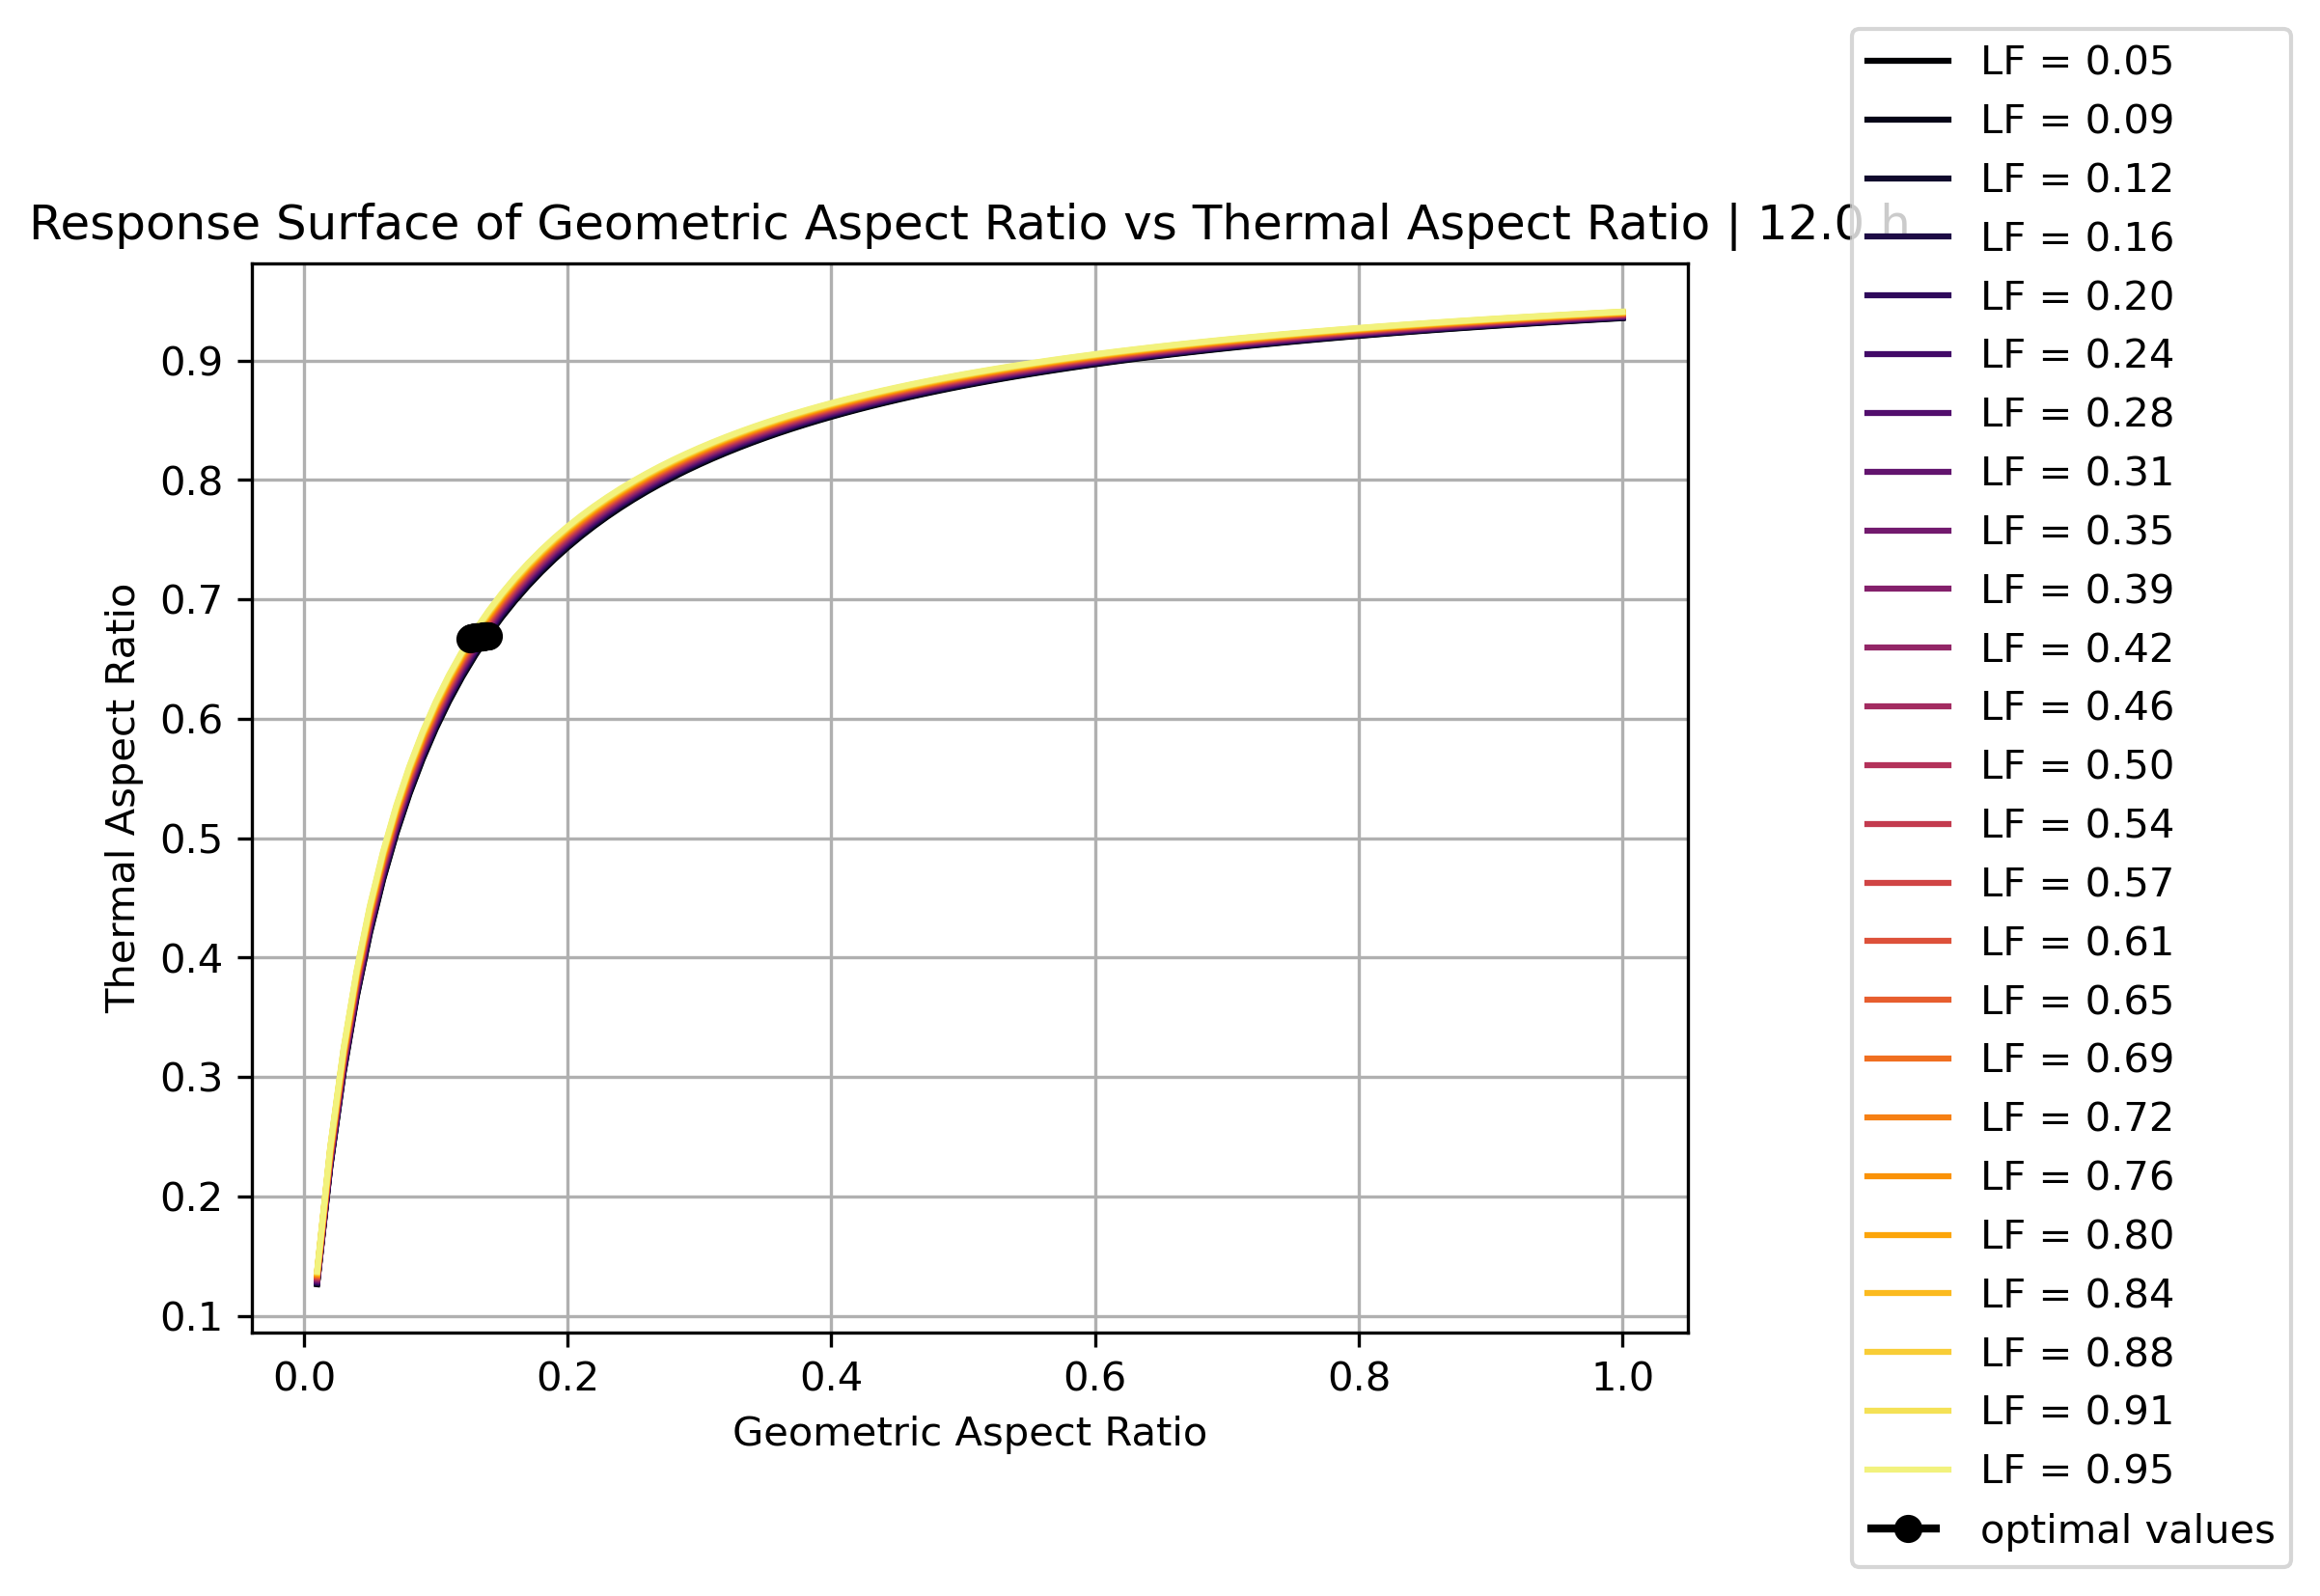

In [19]:
folder = "../Results/Data/"
filename = folder + 'LAES_opti_12h_LFs_ru_025.csv'
opti.plot_surface_response_thermal_aspect_ratio_liquid_filling(jnp.linspace(0.01, 1, 100),
                                                               jnp.linspace(0.05, 0.95, 25),
                                                               12*3600,
                                                               save=True,
                                                               filename=filename)

In [20]:
opti.time = 3600 * 12
LF_array  = jnp.linspace(0.05, 0.95, 200)

def opti_placeholder(lf_eval):
    lf_eval = float(lf_eval)
    opti.tank.LF = lf_eval
    opti.params = opti.make_params(opti, opti.tank)
    optimo_ar, min_bor = opti.optimize_grid_with_refinement(
        t_final=opti.time,
        aspect_ratio_min=0.05,
        aspect_ratio_max=1.0,
        coarse_samples=1000,
        fine_samples=1000,
        verbose=False
    )
    return [optimo_ar, min_bor, lf_eval]

optimos = [opti_placeholder(lf) for lf in LF_array]

# Split the tuples into separate lists for AR and BOR
optimal_AR, min_bor, LF_values = zip(*optimos)
# Save LF_array, optimal_AR, and min_bor to CSV
df_optimos = pd.DataFrame({
    "LF": np.array(LF_array),
    "Optimal_AR": np.array(optimal_AR),
    "Min_BOR": np.array(min_bor)
})

folder = "../Results/Data/"
df_optimos.to_csv(folder + 'LAES_opti_12h_LFs_ru_025_opts.csv', index=False)

#### Visualisation of results

In [ ]:
large_tank.evaporate(12*3600)

#### Vapour temperature

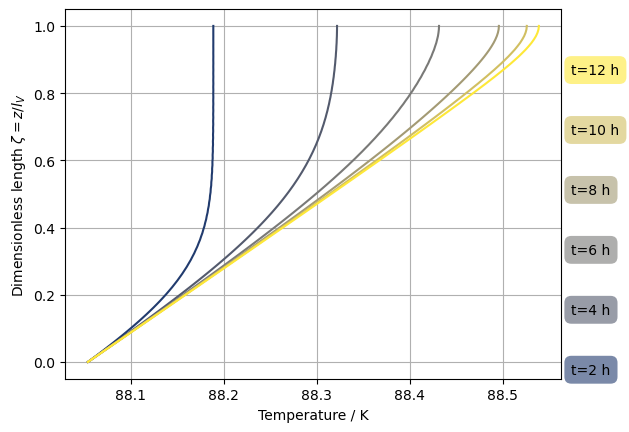

In [36]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

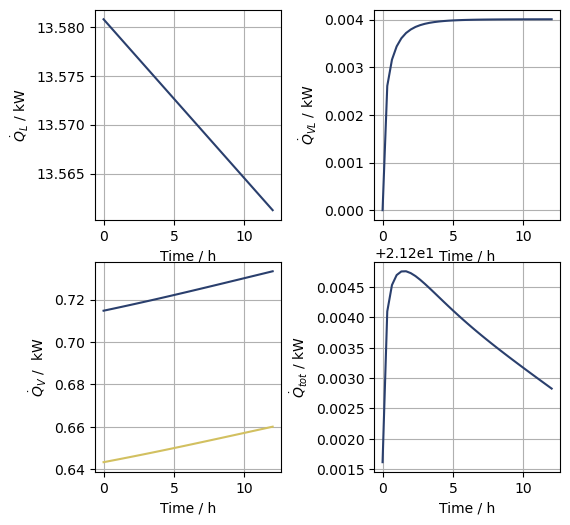

In [37]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

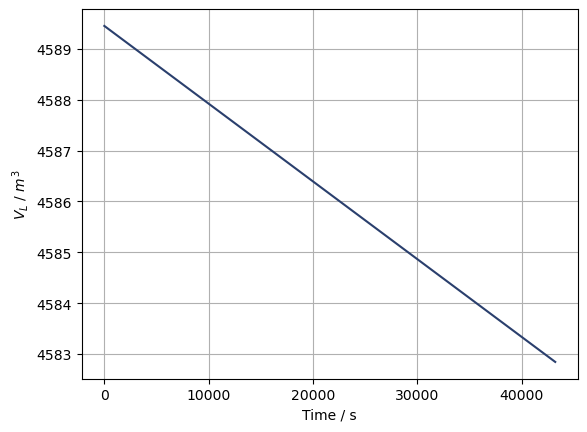

In [38]:
large_tank.plot_V_L()

In [44]:
V_L = large_tank.data["V_L"]
t   = large_tank.data["Time"]

In [45]:
(1.0 - V_L[-1] / V_L[0]) * (86400.0 / t[-1])

np.float64(0.002877874508451672)

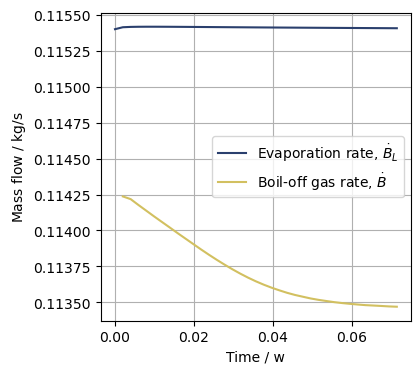

In [41]:
large_tank.plot_BOG(unit='kg/s', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [ ]:
# Import pandas 
import pandas as pd

In [ ]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

In [ ]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

In [ ]:
large_tank.BOR()

In [ ]:
large_tank.data['Time'][-1]

In [ ]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.